In [1]:
import numpy as np
import pandas as pd
import joblib
import optuna
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from category_encoders import TargetEncoder

from utils import (
    load_data, evaluate_model, save_metrics, plot_feature_importance,
    NUMERIC_FEATURES_TREES, MODELS_DIR
)

optuna.logging.set_verbosity(optuna.logging.WARNING)


C:\Users\roman\PycharmProjects\real_estate_ML\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Загрузка данных

In [2]:
X_train, X_test, y_train, y_test, _, _ = load_data()
print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Числовые признаки для деревьев:", NUMERIC_FEATURES_TREES)
print("Целевая: исходная цена в рублях (без логарифма)")
print(f"Диапазон цены: {y_train.min():,.0f} – {y_train.max():,.0f}")


Train: (8819, 12) | Test: (2205, 12)
Числовые признаки для деревьев: ['area', 'rooms', 'floor', 'total_floors', 'minutes_to_metro', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'is_studio']
Целевая: исходная цена в рублях (без логарифма)
Диапазон цены: 3,510,000 – 459,192,280


Препроцессор и фабрика пайплайнов

In [3]:
# Для древесных моделей: без StandardScaler, без log_area
preprocessor = ColumnTransformer(transformers=[
    ("num", "passthrough", NUMERIC_FEATURES_TREES),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["renovation"]),
    ("te",  TargetEncoder(cols=["metro_station"], smoothing=10.0), ["metro_station"]),
])

def make_pipeline(params: dict) -> Pipeline:
    return Pipeline([
        ("prep", preprocessor),
        ("model", RandomForestRegressor(
            random_state=42,
            n_jobs=-1,
            **params
        )),
    ])


Подбор гиперпараметров через Optuna

In [4]:
MAX_NODES = 60_000

def objective(trial):
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 50, 150, step=25),
        "max_leaf_nodes":    trial.suggest_int("max_leaf_nodes", 64, 512, log=True),
        "min_samples_leaf":  trial.suggest_int("min_samples_leaf", 5, 40),
        "max_features":      trial.suggest_categorical("max_features", ["sqrt", 0.5, 1.0]),
    }
        # отсекаем заведомо тяжёлые конфигурации до обучения
    if params["n_estimators"] * params["max_leaf_nodes"] * 2 > MAX_NODES:
        raise optuna.TrialPruned()
    pipe = make_pipeline(params)
    # Учим напрямую на цене в рублях, метрика — MAE
    scores = cross_val_score(pipe, X_train, y_train, cv=5,
                             scoring="neg_mean_absolute_error", n_jobs=-1)
    return -scores.mean()

study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
print("\nЛучшие гиперпараметры:")
for k, v in best_params.items():
    print(f"  {k}: {v}")
print(f"Best CV MAE: {study.best_value:,.0f} руб.")


Best trial: 47. Best value: 1.11118e+07: 100%|██████████| 50/50 [00:24<00:00,  2.03it/s]


Лучшие гиперпараметры:
  n_estimators: 50
  max_leaf_nodes: 503
  min_samples_leaf: 5
  max_features: 0.5
Best CV MAE: 11,111,761 руб.


Финальное обучение и оценка

In [5]:
final_pipeline = make_pipeline(best_params)
final_pipeline.fit(X_train, y_train)

y_pred = final_pipeline.predict(X_test)
metrics = evaluate_model(y_test, y_pred, "RandomForest")

model = final_pipeline.named_steps["model"]
n_nodes = sum(t.tree_.node_count for t in model.estimators_)
print(f"{n_nodes:,} узлов ≈ {n_nodes * 72 / 1e6:.1f} МБ")



=== RandomForest ===
  MAE  =      11,744,000 руб.
  RMSE =      28,675,479 руб.
  MAPE =          20.06 %
  R2   =         0.8355
50,250 узлов ≈ 3.6 МБ


Важность признаков

График сохранён: C:\Users\roman\PycharmProjects\real_estate_ML\ml_dir\reports\feature_importance_randomforest.png


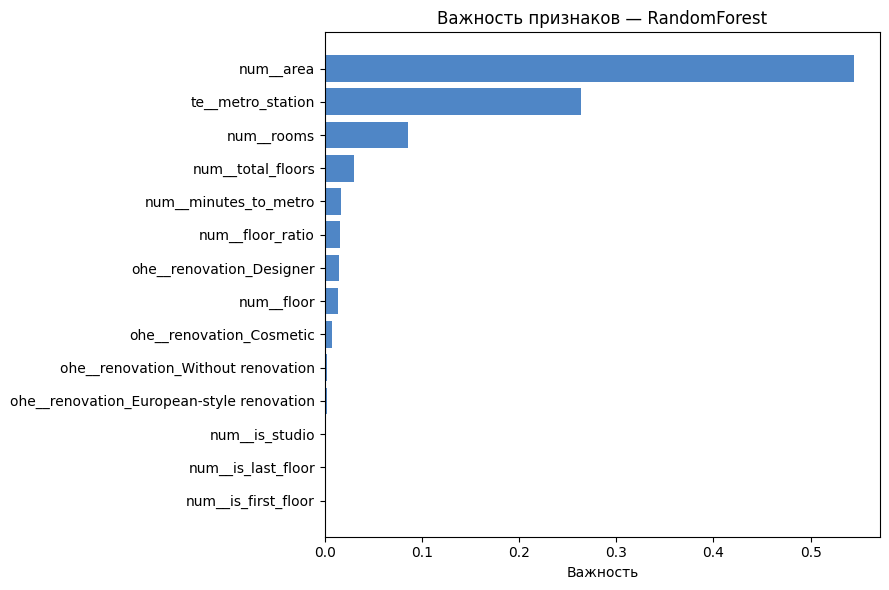

In [6]:
prep = final_pipeline.named_steps["prep"]
model = final_pipeline.named_steps["model"]
feature_names = prep.get_feature_names_out()

importance_df = plot_feature_importance(
    feature_names, model.feature_importances_, "RandomForest", top_n=15
)


Сохранение

In [7]:
joblib.dump(final_pipeline, MODELS_DIR / "random_forest.pkl", compress=3)
save_metrics("RandomForest", metrics, best_params=best_params)
print("Модель и метрики сохранены.")


Метрики сохранены в C:\Users\roman\PycharmProjects\real_estate_ML\ml_dir\ml_models\metrics.json
Модель и метрики сохранены.


Проверка инференса

In [8]:
from inference import predict_random_forest, predict_linear

example = {
    "area": 38.0, "rooms": 1.0, "floor": 5.0, "total_floors": 15,
    "minutes_to_metro": 20.0, "is_studio": 0,
    "metro_station": "Коломенская", "renovation": "Cosmetic",
}

print("=== Однушка на Коломенской ===")
print(f"  Linear:       {predict_linear(example):>15,.0f} руб.")
print(f"  RandomForest: {predict_random_forest(example):>15,.0f} руб.")

example_center = {**example, "metro_station": "Китай-город"}
print("\n=== Та же квартира на Китай-городе ===")
print(f"  Linear:       {predict_linear(example_center):>15,.0f} руб.")
print(f"  RandomForest: {predict_random_forest(example_center):>15,.0f} руб.")


=== Однушка на Коломенской ===
  Linear:            12,300,306 руб.
  RandomForest:      11,572,570 руб.

=== Та же квартира на Китай-городе ===
  Linear:            18,557,168 руб.
  RandomForest:      16,807,867 руб.
